In [129]:
# import libraries
import random
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import datetime
import itertools
import h5py
import math
import matplotlib.dates as mdates
import numpy.ma as ma
import CRPS.CRPS as pscore
from scipy.interpolate import interp1d
import scipy.stats
# fit an empirical cdf to a bimodal dataset
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
import time 
print(np.__version__)

# check pyearth version
# display version
#from matplotlib import pyplot
from tensorflow.python.ops.numpy_ops import np_config 
np_config.enable_numpy_behavior()
#random.seed(1)
#np.random.seed(1)
#tf.random.set_seed(1)

# evaluate multivariate adaptive regression splines for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
# Helpers live in cloud_detection/Helper Functions/ (not on PYTHONPATH by default)
from pathlib import Path
import sys
for _p in (
    Path.cwd() / "Helper Functions",
    Path.cwd().parent / "Helper Functions",
    Path.cwd() / "preprocessing" / "cloud_detection" / "Helper Functions",
):
    _p = _p.resolve()
    if _p.is_dir():
        sys.path.insert(0, str(_p))
        break
from Relative_op_func import *
from Sun_position import *
#from Cloud_detection_v2 import *
%matplotlib inline

1.26.4


# This code was run in scratch and moved to CSL

In [130]:
'''
 we establish a clear sky library (CSL) by sampling 4 clear sky days from our dataset, 
 May 20, August 15, September 23 and October 22 of 2017, with 5-minute frequency.
'''

# define the data location and load data
pardir = r'D:\PVOutputPrediction\preprocessing\cloud_detection'
data_folder = os.path.join(pardir,"Data")
data_path = os.path.join(data_folder, '2017_2019_images_pv_processed.hdf5')
csl_path = os.path.join(pardir,'Clear_sky_library')

# load time stamps
times_trainval = np.load(os.path.join(data_folder,"times_trainval.npy"),allow_pickle=True)
times_test = np.load(os.path.join(data_folder,"times_test.npy"),allow_pickle=True)

# load PV and images
with h5py.File(data_path,'r') as f:
    
    # read in the data
    images_log_trainval = f['trainval']['images_log'][...]
    pv_log_trainval  = f['trainval']['pv_log'][...]

    # read in the data
    images_log_test = f['test']['images_log'][...]
    pv_log_test = f['test']['pv_log'][...]
    
print(images_log_trainval.shape)
print(pv_log_trainval.shape)
print(times_trainval.shape)
print(images_log_test.shape)
print(pv_log_test.shape)
print(times_test.shape)


(349372, 64, 64, 3)
(349372,)
(349372,)
(14003, 64, 64, 3)
(14003,)
(14003,)


In [132]:
# formulate sunny and cloudy test days
csl_dates_2017 = [(2017,5,20),(2017,8,15), (2017,9,23), (2017,10,22)]
csl_dates_2018 = [(2018,2,17),(2018,6,26), (2018,7,8) , (2018,10,13)]
csl_dates_2019 = [(2019,1,25), (2019,6,23), (2019,7,14), (2019,10,14)]
csl_dates_2017 = [datetime.date(day[0],day[1],day[2]) for day in csl_dates_2017]
csl_dates_2018 = [datetime.date(day[0],day[1],day[2]) for day in csl_dates_2018]
csl_dates_2019 = [datetime.date(day[0],day[1],day[2]) for day in csl_dates_2019] #making them datetime.datetime
dates_trainval = np.asarray([times.date() for times in times_trainval]) # getting date of trainval
dates_test = np.asarray([times.date() for times in times_test]) # getting date of trainval

mask_2017 = np.zeros(len(times_trainval),dtype=bool) # initializing mask for date_trainval = csl_dates_trainal
print(mask_2017.shape)
for i in csl_dates_2017:
    mask_2017[np.where(dates_trainval==i)[0]]=1
    
print(mask_2017.shape)

## apply the mask to the dataset
times_csl_2017 = times_trainval[mask_2017]
pv_log_csl_2017 = pv_log_trainval[mask_2017]
images_log_csl_2017 = images_log_trainval[mask_2017]

mask_2018 = np.zeros(len(times_trainval),dtype=bool) 
print(mask_2018.shape)
for i in csl_dates_2018:
    mask_2018[np.where(dates_trainval==i)[0]]=1
    
print(mask_2018.shape)

## apply the mask to the dataset
times_csl_2018 = times_trainval[mask_2018]
pv_log_csl_2018 = pv_log_trainval[mask_2018]
images_log_csl_2018 = images_log_trainval[mask_2018]

mask_2019 = np.zeros(len(times_test),dtype=bool) 
print(mask_2019.shape)
for i in csl_dates_2019:
    mask_2019[np.where(dates_test==i)[0]]=1
    
print(mask_2019.shape)

## apply the mask to the dataset
times_csl_2019 = times_test[mask_2019]
pv_log_csl_2019 = pv_log_test[mask_2019]
images_log_csl_2019 = images_log_test[mask_2019]

"""
times_csl = np.hstack((times_csl_test, times_csl_trainval))
pv_log_csl = np.concatenate((pv_log_csl_test, pv_log_csl_trainval), axis = 0)
images_log_csl = np.concatenate((images_log_csl_test, images_log_csl_trainval), axis = 0)
print('times_csl', times_csl.shape)
print('pv_log_csl', pv_log_csl.shape)
print('images_log_csl', images_log_csl.shape)

"""

csl_sun_center_2017 = np.zeros((images_log_csl_2017.shape[0], 2))
for i in range(len(times_csl_2017)):
    csl_sun_center_2017[i] = sun_position(times_csl_2017[i], images_log_csl_2017[i], plotting = False)
print(csl_sun_center_2017)

csl_sun_center_2018 = np.zeros((images_log_csl_2018.shape[0], 2))
for i in range(len(times_csl_2018)):
    csl_sun_center_2018[i] = sun_position(times_csl_2018[i], images_log_csl_2018[i], plotting = False)
print(csl_sun_center_2018)

csl_sun_center_2019 = np.zeros((images_log_csl_2019.shape[0], 2))
for i in range(len(times_csl_2019)):
    csl_sun_center_2019[i] = sun_position(times_csl_2019[i], images_log_csl_2019[i], plotting = False)
print(csl_sun_center_2019)

np.save(os.path.join(csl_path,'csl_times_2017.npy'),times_csl_2017)
np.save(os.path.join(csl_path,'csl_images_2017.npy'),images_log_csl_2017)
np.save(os.path.join(csl_path,'csl_pv_2017.npy'),pv_log_csl_2017)
np.save(os.path.join(csl_path,'csl_sun_center_2017.npy'),csl_sun_center_2017)

np.save(os.path.join(csl_path,'csl_times_2018.npy'),times_csl_2018)
np.save(os.path.join(csl_path,'csl_images_2018.npy'),images_log_csl_2018)
np.save(os.path.join(csl_path,'csl_pv_2018.npy'),pv_log_csl_2018)
np.save(os.path.join(csl_path,'csl_sun_center_2018.npy'),csl_sun_center_2018)

np.save(os.path.join(csl_path,'csl_times_2019.npy'),times_csl_2019)
np.save(os.path.join(csl_path,'csl_images_2019.npy'),images_log_csl_2019)
np.save(os.path.join(csl_path,'csl_pv_2019.npy'),pv_log_csl_2019)
np.save(os.path.join(csl_path,'csl_sun_center_2019.npy'),csl_sun_center_2019)


(349372,)
(349372,)
(349372,)
(349372,)
(14003,)
(14003,)
[[12.  8.]
 [12.  8.]
 [13.  8.]
 ...
 [38. 56.]
 [38. 56.]
 [38. 56.]]
[[32.  3.]
 [32.  3.]
 [32.  3.]
 ...
 [43. 54.]
 [43. 54.]
 [43. 54.]]
[[35.  3.]
 [36.  3.]
 [36.  3.]
 ...
 [43. 54.]
 [43. 54.]
 [43. 54.]]


2018-02-17: 528 frames; showing 100 (evenly spaced)


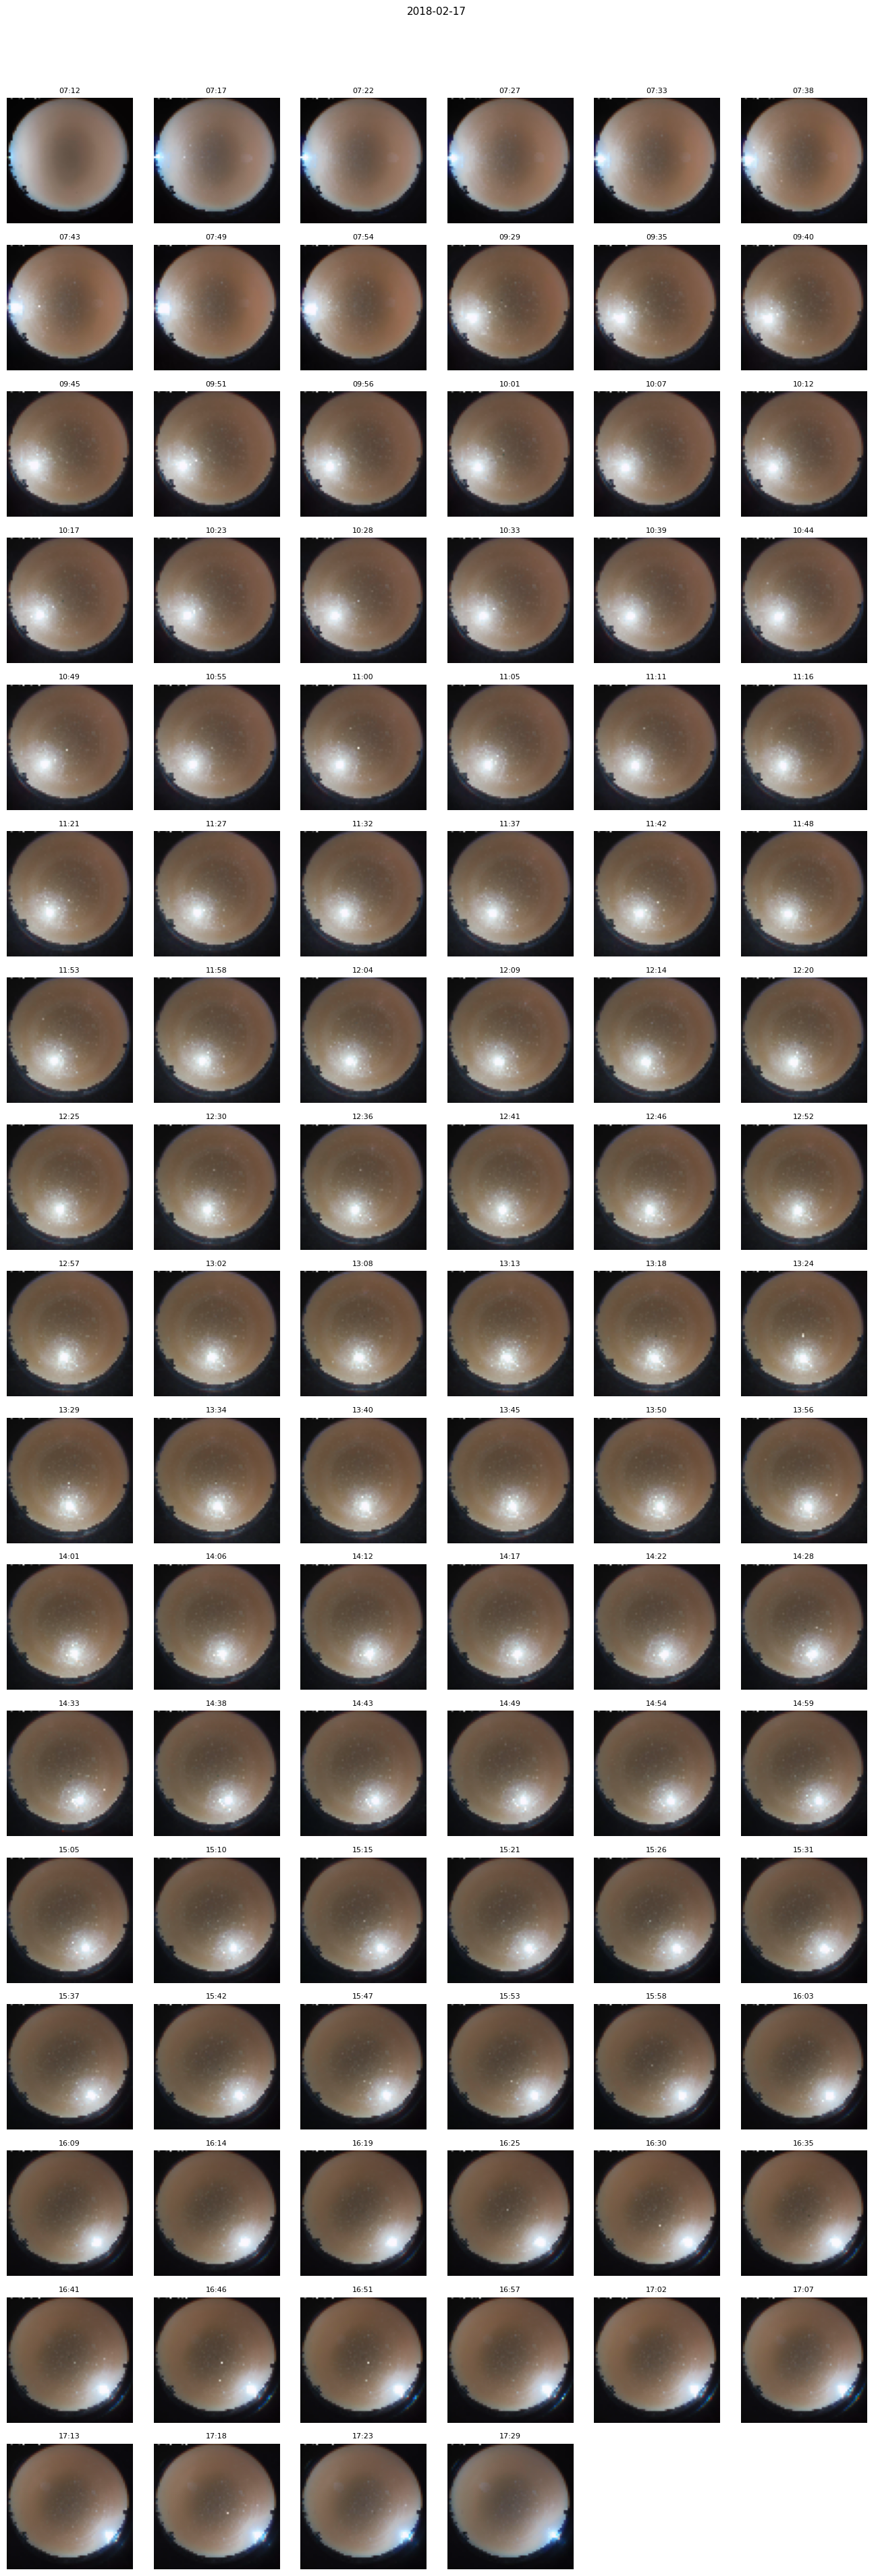

In [128]:
# Images from one calendar day (train/val) — edit day_pick / max_show
day_pick = datetime.date(2018,2,17)
max_show = 100
cols = 6
evenly_space = True  # if True, spread max_show frames across the whole day

mask_day = np.fromiter(
    (t.date() == day_pick for t in times_trainval), dtype=bool, count=len(times_trainval)
)
idx_day = np.flatnonzero(mask_day)
if len(idx_day) == 0:
    raise ValueError(f"No train/val frames on {day_pick}")

if evenly_space and len(idx_day) > max_show:
    pick = np.linspace(0, len(idx_day) - 1, max_show, dtype=int)
    idx = idx_day[pick]
else:
    idx = idx_day[: min(max_show, len(idx_day))]

n = len(idx)
print(f"{day_pick}: {len(idx_day)} frames; showing {n} ({'evenly spaced' if evenly_space else 'first in time order'})")

rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
axes = np.atleast_1d(axes).ravel()
for k, i in enumerate(idx):
    t = times_trainval[i]
    t_str = t.strftime("%H:%M") if hasattr(t, "strftime") else str(t)
    axes[k].imshow(np.clip(images_log_trainval[i], 0, None))
    axes[k].set_title(t_str, fontsize=8)
    axes[k].axis("off")
for k in range(n, len(axes)):
    axes[k].axis("off")
fig.suptitle(str(day_pick), fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
